# OpenABM Realistic Scenario Smoke
This notebook runs multiple realistic policy scenarios through the OpenABM adapter and compares trajectories.

## A. Imports

In [1]:
import sys
from pathlib import Path

# Locate repository root and add extensions package path
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "extensions" / "scenario_api").exists()), None)
if repo_root is None:
    raise RuntimeError("Could not locate extensions/scenario_api from current working directory")

extensions_dir = repo_root / "extensions"
if str(extensions_dir) not in sys.path:
    sys.path.insert(0, str(extensions_dir))

from scenario_api import *


## B. OpenABM Runtime Capability

In [2]:
print("OpenABM available:", is_openabm_available())
print("Runtime-safe update params (sample):")
allowed = supported_runtime_update_params()
print(allowed[:20])
if not is_openabm_available():
    raise RuntimeError("OpenABM runtime is required for this notebook")


OpenABM available: True
Runtime-safe update params (sample):
['allow_clinical_diagnosis', 'app_turned_on', 'app_users_fraction', 'fatality_fraction_0_9', 'fatality_fraction_10_19', 'fatality_fraction_20_29', 'fatality_fraction_30_39', 'fatality_fraction_40_49', 'fatality_fraction_50_59', 'fatality_fraction_60_69', 'fatality_fraction_70_79', 'fatality_fraction_80', 'lockdown_elderly_on', 'lockdown_house_interaction_multiplier', 'lockdown_occupation_multiplier_elderly_network', 'lockdown_occupation_multiplier_primary_network', 'lockdown_occupation_multiplier_retired_network', 'lockdown_occupation_multiplier_secondary_network', 'lockdown_occupation_multiplier_working_network', 'lockdown_on']


/home/ubuntu/OpenABM-Covid19/src/COVID19/model.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## C. Common Baseline Components

In [3]:
base_params = {
    "end_time": 120,
    "test_on_symptoms": 0,
    "lockdown_on": 0,
    "lockdown_random_network_multiplier": 1.0,
    "lockdown_occupation_multiplier_working_network": 1.0,
    "lockdown_occupation_multiplier_secondary_network": 1.0,
}

network_specs = [
    create_network_spec("households", "household", {"population_size": 1000}),
    create_network_spec("work", "activity_structured", {"mean_contacts": 9, "activation_prob": 0.55}),
    create_network_spec("community", "activity_random", {"mean_contacts": 5, "dispersion": 2}),
]

print("Network mapping summary:")
print(network_specs_to_openabm_config(network_specs))


Network mapping summary:
{'household': [{'name': 'households', 'kind': 'household', 'config': {'population_size': 1000}, 'metadata': {}}], 'occupation_like': [{'name': 'work', 'kind': 'activity_structured', 'config': {'mean_contacts': 9, 'activation_prob': 0.55}, 'metadata': {}}], 'random_like': [{'name': 'community', 'kind': 'activity_random', 'config': {'mean_contacts': 5, 'dispersion': 2}, 'metadata': {}}]}


## D. Scenario Definitions

In [4]:
def make_scenario(name, interventions):
    return create_scenario(
        name=name,
        base_params=base_params,
        blocks=[],
        interventions=interventions,
        network_specs=network_specs,
    )

# Baseline: no additional intervention
sc_baseline = make_scenario("baseline", [])

# Moderate response: enable symptomatic testing and moderate lockdown multipliers
moderate = create_parameter_intervention(
    name="moderate_measures",
    start=20,
    end=70,
    params={
        "test_on_symptoms": 1,
        "lockdown_on": 1,
        "lockdown_random_network_multiplier": 0.6,
        "lockdown_occupation_multiplier_working_network": 0.7,
        "lockdown_occupation_multiplier_secondary_network": 0.5,
    },
)
sc_moderate = make_scenario("moderate", [moderate])

# Strong response: earlier and stronger multipliers
strong = create_parameter_intervention(
    name="strong_measures",
    start=15,
    end=80,
    params={
        "test_on_symptoms": 1,
        "lockdown_on": 1,
        "lockdown_random_network_multiplier": 0.35,
        "lockdown_occupation_multiplier_working_network": 0.45,
        "lockdown_occupation_multiplier_secondary_network": 0.25,
    },
)
sc_strong = make_scenario("strong", [strong])

scenarios = [sc_baseline, sc_moderate, sc_strong]
print([s.name for s in scenarios])


['baseline', 'moderate', 'strong']


## E. Run Scenarios Through OpenABM Adapter

In [5]:
results = {}

for sc in scenarios:
    resolved = resolve_scenario(sc)
    model_factory, result_extractor = create_openabm_runner_components(resolved, strict_runtime_updates=True)
    sim = run_scenario(
        resolved,
        steps=100,
        model_factory=model_factory,
        result_extractor=result_extractor,
    )
    results[sc.name] = sim
    print(sc.name, "keys=", list(sim.raw_outputs.keys()), "len=", len(sim.raw_outputs["cases"]))


baseline keys= ['cases', 'infected', 'deaths'] len= 100


moderate keys= ['cases', 'infected', 'deaths'] len= 100


strong keys= ['cases', 'infected', 'deaths'] len= 100


## F. Convert to TimeSeries

In [6]:
series = {name: result_to_timeseries(res, "cases") for name, res in results.items()}
for name, ts in series.items():
    print(name, ts.values[:5])


baseline [0.0, 0.0, 0.0, 0.0, 0.0]
moderate [0.0, 0.0, 0.0, 0.0, 0.0]
strong [0.0, 0.0, 0.0, 0.0, 0.0]


## G. Plot Comparison

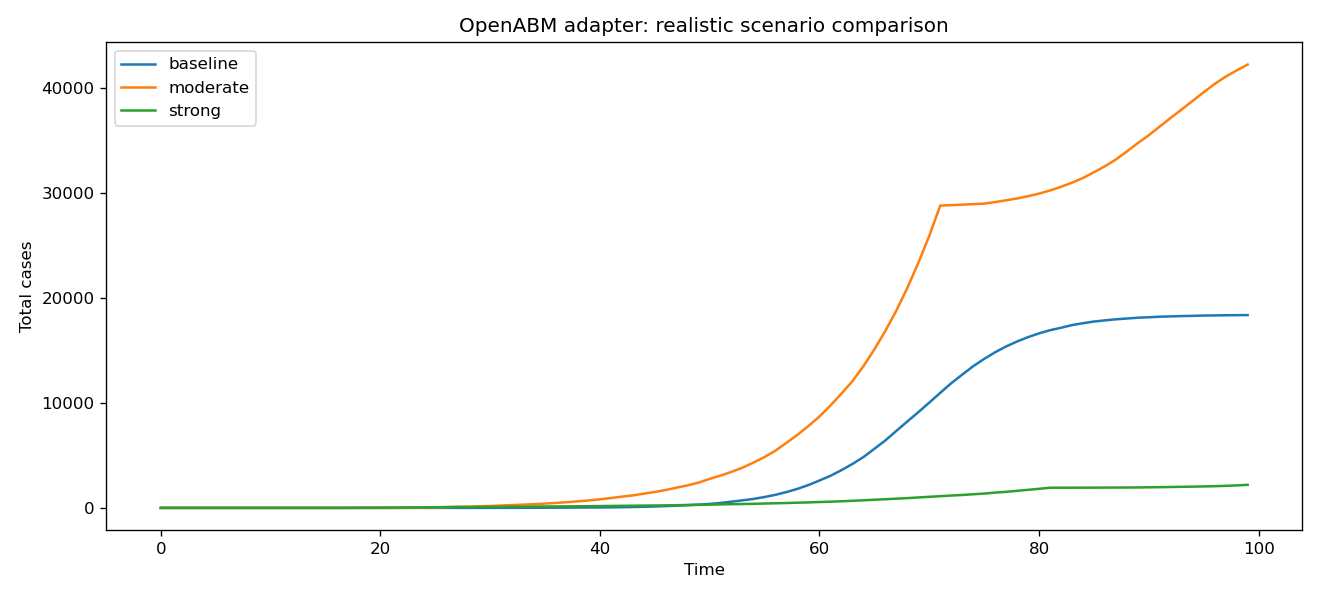

In [7]:
import io
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

fig, ax = plt.subplots(figsize=(11, 5))
for name, ts in series.items():
    ax.plot(ts.times, ts.values, label=name)

ax.set_xlabel("Time")
ax.set_ylabel("Total cases")
ax.set_title("OpenABM adapter: realistic scenario comparison")
ax.legend()
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
